In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# 导入数据集
data = np.loadtxt('../Data/watermelon_3a.csv', delimiter=',')
X = data[:,1:-1]
y = data[:, -1]
y[y == 0] = -1


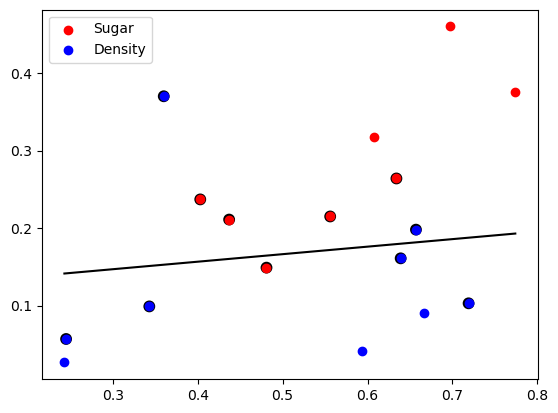

In [40]:
# 使用线性核
svm_linear = SVC(kernel='linear', C=100)
svm_linear.fit(X, y)

# 绘制边界曲线
w = svm_linear.coef_[0]
a = -w[0] / w[1]
xx = np.linspace(X[:, 0].min(), X[:, 0].max())
yy = a * xx - (svm_linear.intercept_[0]) / w[1]
plt.plot(xx, yy, 'k-')
# 圈出支持向量
plt.scatter(svm_linear.support_vectors_[:, 0], svm_linear.support_vectors_[:, 1], facecolors='none', edgecolors='k',linewidths=2.5)
plt.scatter(X[y==1][:,0], X[y==1][:,1],c = 'r', label = 'Sugar')
plt.scatter(X[y==-1][:,0], X[y==-1][:,1],c = 'b', label = 'Density')
plt.legend()
plt.show()


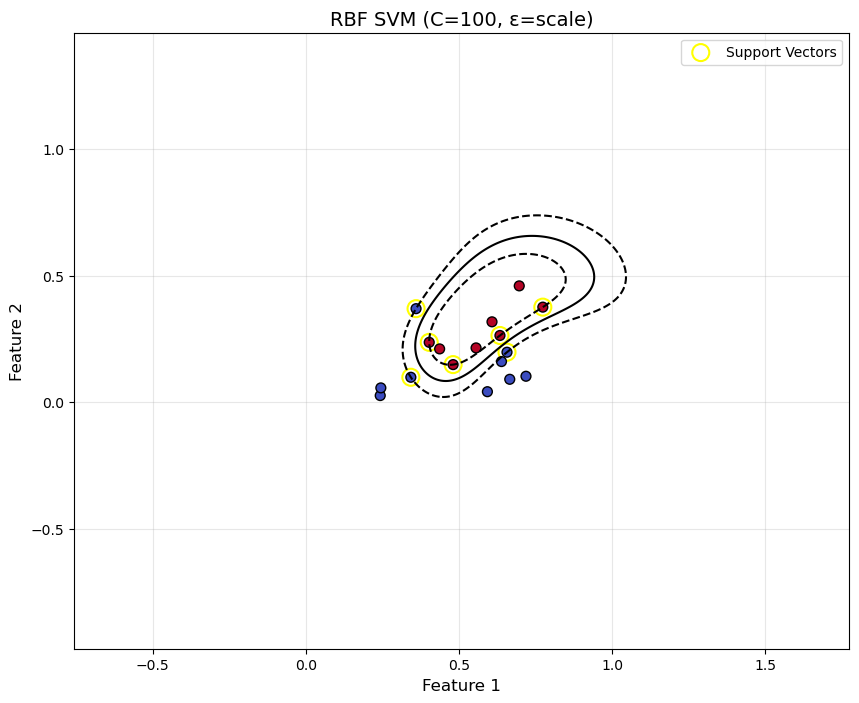

In [45]:
# 使用高斯核
svm_rbf = SVC(kernel='rbf', C=100)
svm_rbf.fit(X, y)

# 绘制决策边界
def plot_rbf_svm_boundary(model, X, y):
    """
    绘制高斯核SVM的决策边界和支持向量
    :param model: 训练好的SVC模型 (kernel='rbf')
    :param X: 特征矩阵 (n_samples, 2)
    :param y: 标签向量 (n_samples,)
    """
    # 1. 创建网格点
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    
    # 2. 计算网格点决策值
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 3. 绘制决策边界和间隔
    plt.figure(figsize=(10, 8))
    plt.contour(xx, yy, Z, 
                levels=[-1, 0, 1],  # 关键等高线
                linestyles=['--', '-', '--'], 
                colors=['k', 'k', 'k'])
    
    # 4. 标注支持向量
    plt.scatter(model.support_vectors_[:, 0], 
                model.support_vectors_[:, 1],
                s=150, facecolors='none', 
                edgecolors='yellow', linewidths=1.5,
                label='Support Vectors')
    
    # 5. 绘制原始数据点
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, 
                edgecolors='k', s=50)
    
    # 6. 添加标注
    plt.xlabel('Feature 1', fontsize=12)
    plt.ylabel('Feature 2', fontsize=12)
    plt.title(f'RBF SVM (C={model.C}, ε={model.gamma})', fontsize=14)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# 使用示例
plot_rbf_svm_boundary(svm_rbf, X, y)
